In [1]:
import numpy as np
from pathlib import Path
import pickle
import math
import matplotlib.pyplot as plt

### Effective ranks of the attention matrices

Given a matrix $A\in\mathbb{R}^{d\times d}$, we can compute its **effective rank** as 
$$\text{erank}(A) = \left\lceil\exp\left(-\sum_{i=1}^d p_i\log(p_i) \right)\right\rceil, \quad p_i = \frac{\sigma_i}{\sum_{j=1}^d \sigma_j}$$

where $\{\sigma_j\}_{j=1=}^d$ are the singular values of $A$.

We apply this to the attention matrices $\{A^{(\ell)}\}_{\ell=1}^L$ of a transformer with $L$ attention layers and to the associated attention rollout matirx $R$.

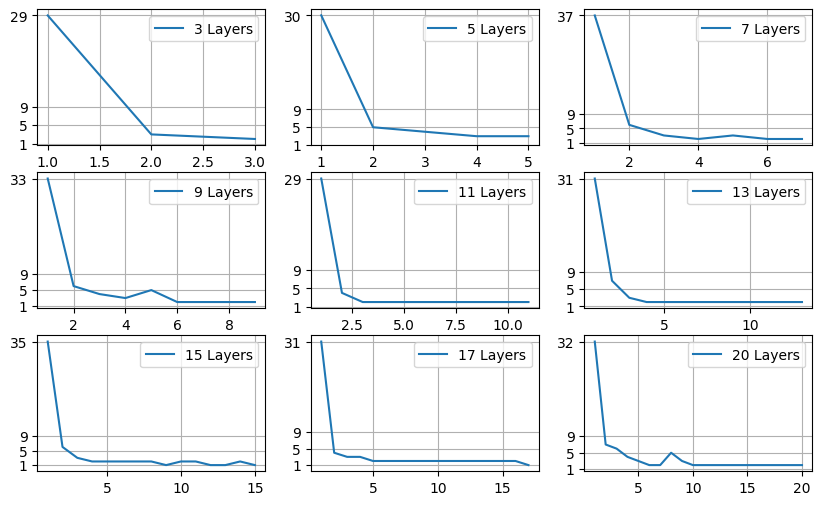

In [2]:
with open("Results/effective_ranks/layerwise_attention_ranks.pkl", "rb") as f:
    attn_rank_dict = pickle.load(f)  

fig, axes = plt.subplots(3, 3, figsize=(10, 6))
axes = axes.flatten()      
    
for i, key in enumerate(attn_rank_dict.keys()):
    ranks = [math.ceil(r) for r in attn_rank_dict[key]]

    x = [int(n) for n in range(1, len(ranks) + 1)]
    num_layers = x[-1]    
    axes[i].plot(x, ranks, label=f"{num_layers} Layers")
    axes[i].set_yticks([1, 5, 9, ranks[0]])
    axes[i].grid(True)
    axes[i].legend()

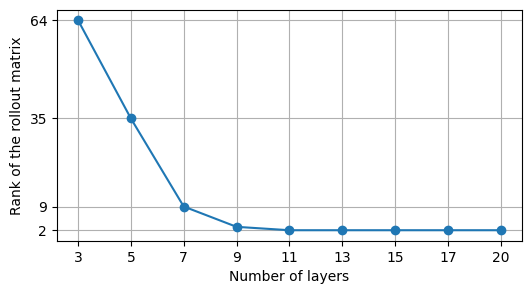

In [3]:
with open("Results/effective_ranks/rollout_ranks.pkl", "rb") as f:
    roll_rank_dict = pickle.load(f)  

plt.figure(figsize=(6, 3))
ranks = [math.ceil(v) for v in roll_rank_dict.values()]
plt.plot(ranks, marker="o")
plt.xticks(range(len(ranks)), [3, 5, 7, 9, 11, 13, 15, 17, 20])
plt.yticks([2, 9, 35, 64])
plt.xlabel("Number of layers")
plt.ylabel("Rank of the rollout matrix")
plt.grid(True)
plt.show()

We can also estimate the mumber of **relevant columns** in the attentin and rollout matrices by computing
$$\rho_{\alpha} = \#\Big\{j\,:\, c_j\geq \alpha\max_{k=1,\ldots,d} c_k\Big\}, \quad\alpha\in (0,1)$$

where $c_j$ indicates the sum of the $j$-ths column. $\rho_{\alpha}$ indicates how many columns in the corresponding matrix have a sum above $\alpha$ times the maximum column sum. It therefore gives an estimate of the $\alpha$ percentage of important columns.

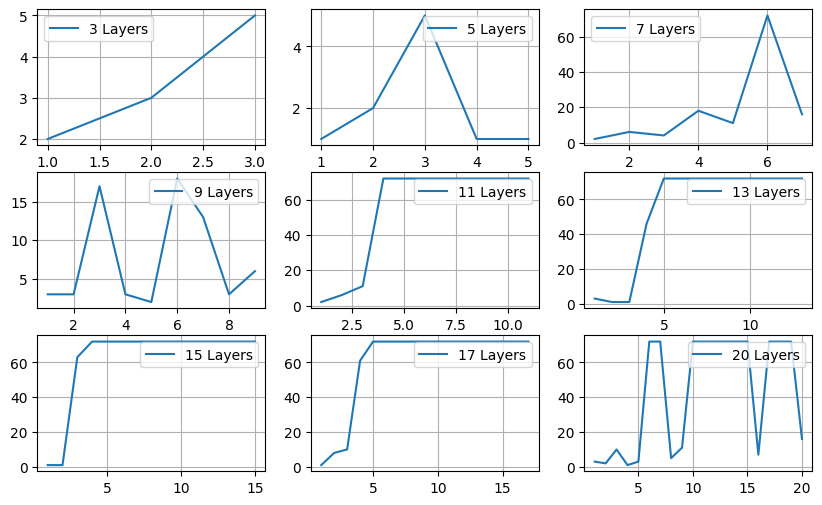

In [10]:
ALPHA = 0.9
ALPHA_s = f"{ALPHA:.2f}".replace(".", "")

with open(f"Results/effective_ranks/layerwise_attention_counts{ALPHA_s}.pkl", "rb") as f:
    attn_count_dict_alpha = pickle.load(f)

fig, axes = plt.subplots(3, 3, figsize=(10, 6))
axes = axes.flatten()      
    
for i, key in enumerate(attn_count_dict_alpha.keys()):
    n_cols = attn_count_dict_alpha[key]['count']
    x = [int(n) for n in range(1, len(n_cols) + 1)]
    num_layers = x[-1]    
    axes[i].plot(x, n_cols, label=f"{num_layers} Layers")
    axes[i].grid(True)
    axes[i].legend()

plt.savefig("rank_alpha.pdf", bbox_inches="tight")

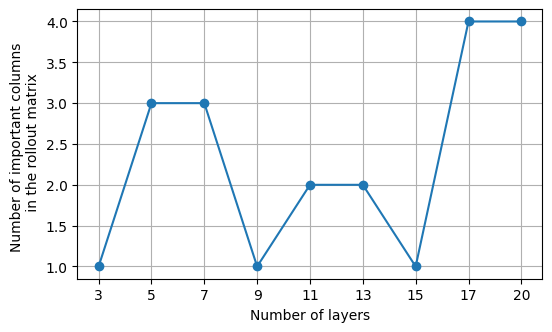

In [9]:
with open(f"Results/effective_ranks/rollout_counts{ALPHA_s}.pkl", "rb") as f:
    roll_count_dict_alpha = pickle.load(f)

plt.figure(figsize=(6, 3.5))
ranks = [v['count'] for v in roll_count_dict_alpha.values()]
plt.plot(ranks, marker="o")
plt.xticks(range(len(ranks)), [3, 5, 7, 9, 11, 13, 15, 17, 20])
plt.xlabel("Number of layers")
plt.ylabel("Number of important columns \n in the rollout matrix")
plt.grid(True)
plt.show()